In [1]:
from pyscf import gto, scf, cc

a = 2 # 2aB
nH = 2
atoms = ""
for i in range(nH):
    atoms += f"H {i*a:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()
# et = mycc.ccsd_t()
# print(mycc.e_tot + et)
mycc.energy()

System: uname_result(system='Linux', node='yichi-thinkpad', release='4.4.0-26100-Microsoft', version='#7705-Microsoft Fri Jan 01 08:00:00 PST 2016', machine='x86_64')  Threads 12
Python 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
numpy 1.24.3  scipy 1.14.1  h5py 3.12.1
Date: Mon Feb 16 20:45:56 2026
PySCF version 2.8.0
PySCF path  /home/yichi/research/software/lno_pyscf
GIT HEAD (branch master) ef75f4190e4de208685670651dc6c467f72b6794

[ENV] PYSCF_EXT_PATH /home/yichi/research/software/pyscf
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 2
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000

-0.039641400885220515

In [2]:
# example for PT2
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 100,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'ccsd_pt2',
            'dt':0.005,
            'free_projection':False,
            'fp_abs': False,
            'group': False,
            'ad_mode': None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (1, 1)
# Number of basis functions: 2
# Number of Cholesky vectors: 3
#


In [3]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, observable, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
# ept_sp = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2
# ept = jnp.array(jnp.sum(ept_sp) / prop.n_walkers)
prop_data["e_estimate"] = e_init
# eci = trial.calc_energy(
#     prop_data['walkers'], ham_data, wave_data)
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# norb: 2
# nelec: (1, 1)
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 100
# seed: 2
# walker_type: rhf
# trial: ccsd_pt2
# dt: 0.005
# free_projection: False
# fp_abs: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# ene0: 0.0
# n_batch: 1
# max_error: 0.001
-1.056429882169736
4.440892098500626e-16


In [4]:
from ad_afqmc.prop_unrestricted import wavefunctions_restricted
amp_file="amplitudes.npz"
amplitudes = np.load(amp_file)
t1 = jnp.array(amplitudes["t1"])
t2 = jnp.array(amplitudes["t2"])
wave_data["t1"] = t1
wave_data["t2"] = t2

trial_stocc = wavefunctions_restricted.stoccsd(trial.norb, trial.nelec, n_batch=options["n_batch"])
trial_stocc.nslater = 100
wave_data['stocc'] = trial_stocc.get_stocc(wave_data, prop_data)
e_stocc = trial.calc_energy(wave_data['stocc'], ham_data, wave_data)
o_stocc = trial.calc_overlap(wave_data['stocc'], wave_data)
e_stocc = jnp.sum(o_stocc * e_stocc) / jnp.sum(o_stocc)

print(e_stocc-mycc.e_tot)

(0.0010982593174364563-3.6358964896545714e-17j)


In [5]:
from jax import vmap

def get_stocc(self, wave_data: dict, prop_data: dict):
    nO = self.nelec[0]
    nslater = self.nslater
    t1 = wave_data["t1"]

    # t_iajb = tau_gia tau_gjb
    tau, _ = self.decompose_t2(wave_data)

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            nslater,
            tau.shape[0],
        ),
    )

    # e^{t1+x*tau2}
    t1s = jnp.array([t1 + 0.0j] * nslater)
    xtau =jnp.einsum("wg,gia->wia", fields, tau)
    ops = t1s + xtau

    def _exp_tau(op, sd):
        # for matrix that only have one block nonzero exp(tau_ia) = 1 + tau_ia true
        tau_full = jnp.eye(self.norb, dtype=jnp.complex128)
        exp_op = tau_full.at[:nO, nO:].set(op)
        # exp_tau = jsp.linalg.expm(tau_full)
        return exp_op.T @ sd

    # Initial slater determinants
    init_sd = jnp.array([jnp.eye(self.norb)[:,:nO] + 0.0j] * nslater)
    stocc = vmap(_exp_tau)(ops, init_sd)

    return stocc, xtau

def get_xtau(self, wave_data: dict, prop_data: dict):
    nslater = self.nslater

    # t_iajb = tau_gia tau_gjb
    tau, _ = self.decompose_t2(wave_data)

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            nslater,
            tau.shape[0],
        ),
    )

    xtau =jnp.einsum("sg,gia->sia", fields, tau) # (nslater,nocc,nvir)

    return xtau

In [9]:
amp_file="amplitudes.npz"
amplitudes = np.load(amp_file)
t1 = jnp.array(amplitudes["t1"])
t2 = jnp.array(amplitudes["t2"])
wave_data["t1"] = t1
wave_data["t2"] = t2

trial_stocc.nslater = 100
wave_data['stocc'], wave_data['xtau'] = get_stocc(trial_stocc, wave_data, prop_data)
e_stocc = trial.calc_energy(wave_data['stocc'], ham_data, wave_data)
o_stocc = trial.calc_overlap(wave_data['stocc'], wave_data)
e_stocc = jnp.sum(o_stocc * e_stocc) / jnp.sum(o_stocc)

print(e_stocc-mycc.e_tot)

(-0.0004212094373732267+2.671022096048122e-18j)


In [ ]:
# @partial(jit, static_argnums=0)
import jax
from jax import lax
import opt_einsum as oe

def xtau_exp_energy_one_walker(
        self,
        walker: jax.Array,
        h0: float,
        h1: jax.Array,
        chol: jax.Array,
        xtau: jax.Array,
        )-> complex:
    # <exp(xtau)HF|H|walker>

    norb = self.norb
    nocc = self.nelec[0]
    one = jnp.eye(norb, dtype=jnp.complex128)
    exp_xtau = one.at[:nocc, nocc:].set(xtau)
    slater = jnp.eye(norb, dtype=jnp.complex128)[:,:nocc]
    slater = exp_xtau.T @ slater

    green = (walker @ (
            jnp.linalg.inv(slater.T.conj() @ walker)
                ) @ slater.T.conj()
                ).T
    
    hg = oe.contract("pq,pq->", h1, green, backend="jax")
    e1 = 2 * hg
    lg = oe.contract("gpr,qr->gpq", chol, green, backend="jax")
    e2_1 = 2 * jnp.sum(oe.contract('gpp->g', lg, backend="jax")**2)
    e2_2 = oe.contract('gpq,gqp->',lg,lg, backend="jax")
    e2 = e2_1 - e2_2

    olp = jnp.linalg.det(slater.T.conj() @ walker) ** 2
    
    return (h0 + e1 + e2)*olp, olp

def xtau_cisd_energy_one_walker(
    self,
    walker: jax.Array,
    h0: float,
    h1: jax.Array,
    chol: jax.Array,
    xtau: jax.Array,
) -> complex:
    # <[1 + xtau + (xtau)^2]HF|H|walker>
    
    ci1 = xtau
    ci2 = oe.contract('ia,jb->iajb', xtau, xtau, backend='jax')
    nocc = self.nelec[0]
    green = (walker.dot(jnp.linalg.inv(walker[:nocc, :]))).T
    green_occ = green[:, nocc:]
    greenp = jnp.vstack((green_occ, -jnp.eye(self.norb - nocc)))

    rot_chol = chol[:, : self.nelec[0], :]
    hg = oe.contract("pj,pj->", h1[:nocc, :], green, backend="jax")

    # 1 body energy
    # ref
    e1_0 = 2 * hg

    # single excitations
    ci1g = oe.contract("pt,pt->", ci1, green_occ, backend="jax")
    e1_1_1 = 4 * ci1g * hg
    gpci1 = greenp @ ci1.T
    ci1_green = gpci1 @ green
    e1_1_2 = -2 * oe.contract("ij,ij->", h1, ci1_green, backend="jax")
    e1_1 = e1_1_1 + e1_1_2

    # double excitations
    ci2g_c = oe.contract("ptqu,pt->qu", ci2, green_occ, backend="jax")
    ci2g_e = oe.contract("ptqu,pu->qt", ci2, green_occ, backend="jax")
    ci2_green_c = (greenp @ ci2g_c.T) @ green
    ci2_green_e = (greenp @ ci2g_e.T) @ green
    ci2_green = 2 * ci2_green_c - ci2_green_e
    ci2g = 2 * ci2g_c - ci2g_e
    gci2g = oe.contract("qu,qu->", ci2g, green_occ, backend="jax")
    e1_2_1 = 2 * hg * gci2g
    e1_2_2 = -2 * oe.contract("ij,ij->", h1, ci2_green, backend="jax")
    e1_2 = e1_2_1 + e1_2_2
    e1 = e1_0 + e1_1 + e1_2

    # two body energy
    # ref
    lg = oe.contract("gpj,pj->g", rot_chol, green, backend="jax")
    # lg1 = jnp.einsum("gpj,pk->gjk", rot_chol, green, optimize="optimal")
    lg1 = oe.contract("gpj,qj->gpq", rot_chol, green, backend="jax")
    e2_0_1 = 2 * lg @ lg
    e2_0_2 = -jnp.sum(vmap(lambda x: x * x.T)(lg1))
    e2_0 = e2_0_1 + e2_0_2

    # single excitations
    e2_1_1 = 2 * e2_0 * ci1g
    lci1g = oe.contract("gij,ij->g", chol, ci1_green, backend="jax")
    e2_1_2 = -2 * (lci1g @ lg)

    ci1g1 = ci1 @ green_occ.T
    # e2_1_3 = jnp.einsum("gpq,gpq->", glgpci1, lg1, optimize="optimal")
    e2_1_3_1 = oe.contract("gpq,gqr,rp->", lg1, lg1, ci1g1, backend="jax")
    lci1 = oe.contract(
            "git,pt->gip",
            chol[:, :, self.nelec[0] :],
            ci1,
            backend="jax"
        )
    lci1g = oe.contract("gip,qi->gpq", lci1, green, backend="jax")
    e2_1_3_2 = -oe.contract("gpq,gqp->", lci1g, lg1, backend="jax")
    e2_1_3 = e2_1_3_1 + e2_1_3_2
    e2_1 = e2_1_1 + 2 * (e2_1_2 + e2_1_3)

    # double excitations
    e2_2_1 = e2_0 * gci2g
    lci2g = oe.contract("gij,ij->g", chol, ci2_green, backend="jax")
    e2_2_2_1 = -lci2g @ lg

    def scanned_fun(carry, x):
        chol_i, rot_chol_i = x
        gl_i = oe.contract("pj,ji->pi", green, chol_i, backend="jax")
        lci2_green_i = oe.contract(
            "pi,ji->pj", rot_chol_i, ci2_green, backend="jax"
        )
        carry[0] += 0.5 * oe.contract(
            "pi,pi->", gl_i, lci2_green_i, backend="jax"
        )
        glgp_i = oe.contract("pi,it->pt", gl_i, greenp, backend="jax")
        l2ci2_1 = oe.contract(
            "pt,qu,ptqu->",
            glgp_i,
            glgp_i,
            ci2,
            backend="jax"
        )
        l2ci2_2 = oe.contract(
            "pu,qt,ptqu->",
            glgp_i,
            glgp_i,
            ci2,
            backend="jax"
        )
        carry[1] += 2 * l2ci2_1 - l2ci2_2
        return carry, 0.0

    [e2_2_2_2, e2_2_3], _ = lax.scan(scanned_fun, [0.0, 0.0], (chol, rot_chol))
    e2_2_2 = 4 * (e2_2_2_1 + e2_2_2_2)

    e2_2 = e2_2_1 + e2_2_2 + e2_2_3

    e2 = e2_0 + e2_1 + e2_2

    # overlap
    olp_hf = jnp.linalg.det(walker[:nocc,:nocc]) ** 2
    o1 = 2 * ci1g
    o2 = gci2g
    olp_cisd = (1.0 + o1 + o2) * olp_hf

    return h0*olp_cisd + (e1 + e2)*olp_hf, olp_cisd

In [14]:
def xtau_exp_cisd_energy_olp_one_walker(
        self,
        walker: jax.Array,
        h0: float,
        h1: jax.Array,
        chol: jax.Array,
        xtau: jax.Array,
        ):

        e_exp, o_exp = xtau_exp_energy_one_walker(self, walker, h0, h1, chol, xtau)
        e_cisd, o_cisd = xtau_cisd_energy_one_walker(self, walker, h0, h1, chol, xtau)

        de = e_exp - e_cisd
        do = o_exp - o_cisd
        
        return (de, do)

In [15]:
e_exp, o_exp \
    = xtau_exp_energy_one_walker(
        trial,
        prop_data['walkers'][0],
        ham_data['h0'],
        (ham_data['h1'][0]+ham_data['h1'][0])/2,
        ham_data['chol'].reshape(-1,trial.norb,trial.norb),
        wave_data['xtau'][0])

print(e_exp, o_exp)

(-1.1390651837108074+3.0475503741190046e-16j) (1+0j)


In [16]:
e_ci, o_ci \
    = xtau_cisd_energy_one_walker(
        trial,
        prop_data['walkers'][0],
        ham_data['h0'],
        (ham_data['h1'][0]+ham_data['h1'][0])/2,
        ham_data['chol'].reshape(-1,trial.norb,trial.norb),
        wave_data['xtau'][0])

print(e_ci, o_ci)

(-1.1390651837108074-2.829118331812411e-16j) (1+0j)


In [ ]:
# xtau = wave_data['xtau'][0]
# xtau_sq = oe.contract('ia,jb->iajb', xtau, xtau, backend='jax')
# ecorr = xtau_cisd_energy(
#     trial,
#     prop_data['walkers'][0],
#     ham_data['h0'],
#     (ham_data['h1'][0]+ham_data['h1'][0])/2,
#     ham_data['chol'].reshape(-1,trial.norb,trial.norb),
#     xtau,
#     xtau_sq,
# )
# print(ecorr)

(-1.0646611581474756-6.007804742909679e-17j)


In [ ]:
walker = prop_data['walkers'][0]

def get_sto_differece(self, walker, ham_data, wave_data):

    def scan_xtau_one_walker(carry, xtau: jax.Array):
        (de, do) = xtau_exp_cisd_energy_olp_one_walker(
            self,
            walker,
            ham_data['h0'],
            (ham_data['h1'][0]+ham_data['h1'][0])/2,
            ham_data['chol'].reshape(-1,trial.norb,trial.norb),
            xtau,
            )
        return carry, (de, do)

    init_carry = 0.0
    _, (des, dos) = lax.scan(scan_xtau_one_walker, init_carry, wave_data['xtau'])

    de = jnp.sum(des)
    do = jnp.sum(dos)

    return de, do



(100,) (100,)


In [46]:
print(jnp.abs(des).max())
print(jnp.abs(dos).max())

1.1123843461371881e-15
0.0


In [73]:
e_stocc = trial.calc_energy(wave_data['stocc'], ham_data, wave_data)

In [74]:
exp_t_one_t = e_stocc - energies

/home/yichi/research/software/miniconda3/envs/lno_pyscf_afqmc/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/yichi/research/software/miniconda3/envs/lno_pyscf_afqmc/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


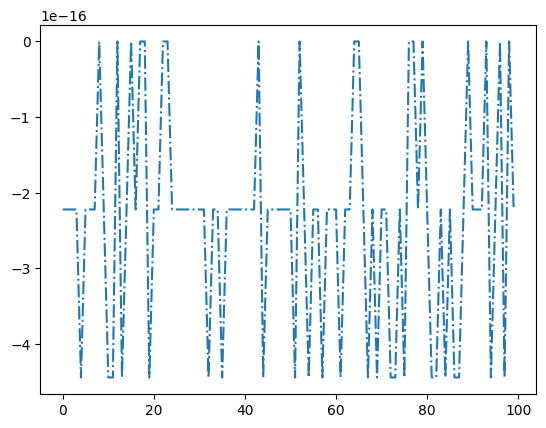

In [ ]:
from matplotlib import pyplot as plt
plt.plot(exp_t_one_t,'-.') # exp(t) - (1 + t)
plt.show()

In [ ]:
# from jax import lax

# @partial(jit, static_argnums=(0,3,4))
# def stocc_block_scan(
#     self,
#     prop_data: dict,
#     ham_data: dict,
#     prop,
#     trial,
#     wave_data: dict,
# ):
#     """Block scan function. Propagation and energy calculation."""
#     prop_data["key"], subkey = random.split(prop_data["key"])
#     fields = random.normal(
#         subkey,
#         shape=(
#             self.n_prop_steps,
#             prop.n_walkers,
#             self.n_chol,
#         ),
#     )
#     _step_scan_wrapper = lambda x, y: self._step_scan(
#         x, y, ham_data, prop, trial, wave_data
#     )
#     prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
#     prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
#         prop_data["weights"]
#     )

#     prop_data = prop.orthonormalize_walkers(prop_data)
#     prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
#     # otg, eg, et = trial.calc_energy_mixed(prop_data["walkers"],ham_data,wave_data)
#     eg = jnp.real(trial.calc_energy(prop_data["walkers"],ham_data,wave_data))
#     (et, ot) = trial_stocc.calc_energy_overlap_stocc(prop_data["walkers"], ham_data, wave_data)
#     t1, t2, e0, e1 = trial.calc_energy_pt(prop_data["walkers"], ham_data, wave_data)
    
#     eg = jnp.where(
#         jnp.abs(eg - prop_data["e_estimate"]) > jnp.sqrt(2.0 / prop.dt),
#         prop_data["e_estimate"],
#         eg,
#     )
    
#     wt = prop_data["weights"]
#     wp = wt * ot / prop_data["overlaps"]

#     blk_wt = jnp.sum(wt)
#     blk_wp = jnp.sum(wp)
#     blk_eg = jnp.sum(eg*wt) / blk_wt
#     blk_et = jnp.sum(et*wp) / blk_wp
#     blk_t1 = jnp.sum(t1*wt) / blk_wt
#     blk_t2 = jnp.sum(t2*wt) / blk_wt
#     blk_e0 = jnp.sum(e0*wt) / blk_wt
#     blk_e1 = jnp.sum(e1*wt) / blk_wt

#     prop_data["pop_control_ene_shift"] = (
#         0.9 * prop_data["pop_control_ene_shift"] + 0.1 * blk_eg
#         )

#     return prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)

# @partial(jit, static_argnums=(0,3,4))
# def stocc_sr_scan(
#     self,
#     prop_data: dict,
#     ham_data: dict,
#     prop,
#     trial,
#     wave_data: dict,
# ):
        
#     def _block_scan_wrapper(x,_):
#         return stocc_block_scan(self,x,ham_data,prop,trial,wave_data)
    
#     prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)\
#         = lax.scan(
#         _block_scan_wrapper, prop_data, None, length = self.n_ene_blocks
#     )
#     prop_data = prop.stochastic_reconfiguration_local(prop_data)
#     prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
#     return prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)

# @partial(jit, static_argnums=(0,3,4))
# def stocc_obvervation(
#     self,
#     prop_data: dict,
#     ham_data: dict,
#     prop,
#     trial,
#     wave_data: dict,
# ):
#     def _sr_block_scan_wrapper(x,_):
#         return stocc_sr_scan(self, x, ham_data, prop, trial, wave_data)

#     prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
#     prop_data["n_killed_walkers"] = 0
#     prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]
#     prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)\
#         = lax.scan(
#         _sr_block_scan_wrapper, prop_data, None, length = self.n_sr_blocks
#     )
#     prop_data["n_killed_walkers"] /= (
#         self.n_sr_blocks * self.n_ene_blocks * prop.n_walkers
#     )

#     wt = jnp.sum(blk_wt)
#     wp = jnp.sum(blk_wp)
#     eg = jnp.sum(blk_eg * blk_wt) / wt
#     et = jnp.sum(blk_et * blk_wp) / wp
#     t1 = jnp.sum(blk_t1 * blk_wt) / wt
#     t2 = jnp.sum(blk_t2 * blk_wt) / wt
#     e0 = jnp.sum(blk_e0 * blk_wt) / wt
#     e1 = jnp.sum(blk_e1 * blk_wt) / wt
#     ept = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2

#     return prop_data, (wt, wp, eg, et, ept)

In [ ]:
# e0 = trial._calc_energy_restricted(prop_data["walkers"][0], ham_data, wave_data)

In [ ]:
# nsample = 50
# samples = np.zeros((nsample, 5))
# samples[0,:] = [100, 100, e0.real, e_stocc.real, ept.real]
# for n in range(1,nsample):
#     prop_data, (wt, wp, e_hf, e_stocc, e_ccpt) \
#         = stocc_obvervation(sampler, prop_data, ham_data, prop, trial, wave_data)
#     print(n, wt.real, wp.real, e_hf.real, e_stocc.real, e_ccpt.real)
#     samples[n,:] = [wt.real, wp.real, e_hf.real, e_stocc.real, e_ccpt.real]

1 498.72530484901927 524.3314754899088 -108.6266333652964 -108.66691998957134 -108.66894095081797
2 499.77120928853736 537.1614839209217 -108.66698381779851 -108.66872255810199 -108.66764385752946
3 500.4308181798255 546.0503674207326 -108.69453492732063 -108.67149713717666 -108.67138910708425
4 499.3643244641903 535.1265662794136 -108.65773798709363 -108.67020781155438 -108.66985380855101
5 499.1400164638497 531.9149416309743 -108.65398786414882 -108.66978289206536 -108.66806624317856
6 499.22745472272237 533.411216193482 -108.65754570584447 -108.6682718653657 -108.66801930253376
7 498.707347829935 527.2876874216821 -108.63555541685528 -108.66781317514682 -108.66851007784655
8 498.9209043035468 527.697364086276 -108.63730535032352 -108.66819284355614 -108.66970281582614
9 498.6570826635715 527.8574199904735 -108.63532572172879 -108.66913659438637 -108.66991821544546
10 498.91975091951986 529.7452972192235 -108.64198787397599 -108.66843240411464 -108.66753545295502
11 500.1303552010162

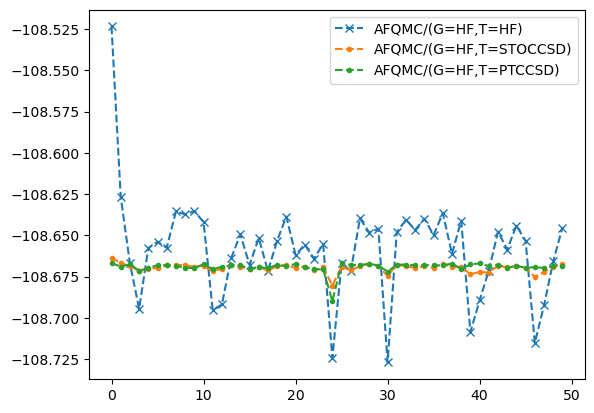

In [ ]:
# from matplotlib import pyplot as plt
# plt.plot(samples[:,2],'x--',label='AFQMC/(G=HF,T=HF)')
# plt.plot(samples[:,3],'.--',label='AFQMC/(G=HF,T=STOCCSD)')
# plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
# plt.legend()
# plt.show()

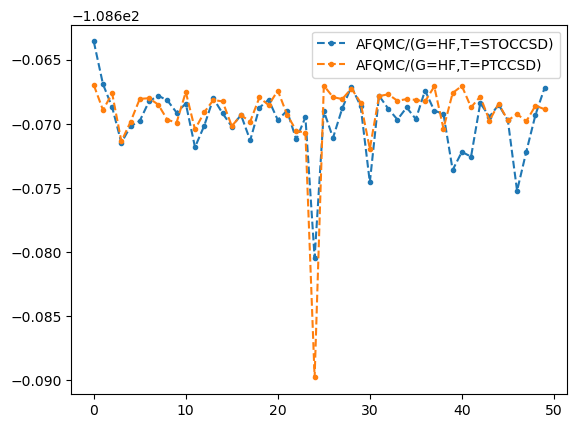

In [ ]:
# plt.plot(samples[:,3],'.--',label='AFQMC/(G=HF,T=STOCCSD)')
# plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
# plt.legend()
# plt.show()

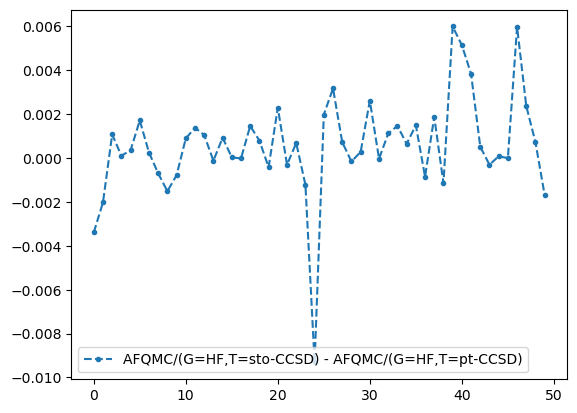

In [ ]:
# plt.plot(samples[:,4]-samples[:,3],'.--',label='AFQMC/(G=HF,T=sto-CCSD) - AFQMC/(G=HF,T=pt-CCSD)')
# # plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
# plt.legend()
# plt.show()